### Lecture et parsing du fichier JSONL de logs HTTP → DataFrame

In [6]:
import json
import pandas as pd

path = "../ml/data/http_events.jsonl"

rows = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line=line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_http = pd.DataFrame(rows)
#df_http.head()
df_http

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,timestamp,source_ip,service,method,path,query,user_agent,content_type,body
0,2026-01-31T22:12:02.868745Z,172.20.0.1,http,GET,/admin,,curl/7.81.0,,
1,2026-01-31T22:14:40.849348Z,172.20.0.1,http,GET,/login,user=%27%20OR%201%3D1,curl/7.81.0,,
2,2026-01-31T22:38:22.559209Z,172.20.0.1,http,GET,/admin,,curl/7.81.0,,
3,2026-01-31T22:38:22.578424Z,172.20.0.1,http,GET,/login,user=%27%20OR%201%3D1,curl/7.81.0,,
4,2026-02-01T00:44:34.215662Z,172.20.0.1,http,GET,/,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,,
...,...,...,...,...,...,...,...,...,...
130,2026-03-01T02:18:19.947555Z,172.20.0.1,http,GET,/admin,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,,
131,2026-03-01T02:18:30.708274Z,172.20.0.1,http,GET,/admin,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,,
132,2026-03-01T02:18:32.602996Z,172.20.0.1,http,GET,/admin,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,,
133,2026-03-04T03:26:16.996323Z,172.20.0.1,http,GET,/search,q=AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,curl/7.81.0,,


### Graphiques HTTP (top paths, top queries)

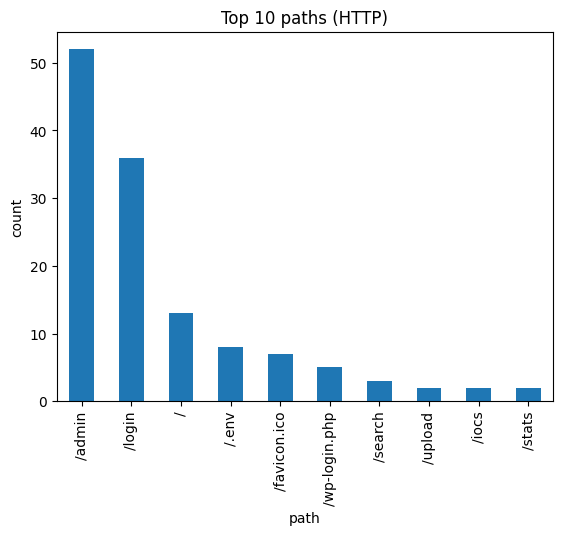

In [2]:
import matplotlib.pyplot as plt

df_http["path"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 paths (HTTP)")
plt.xlabel("path")
plt.ylabel("count")
plt.show()

### Top Queries

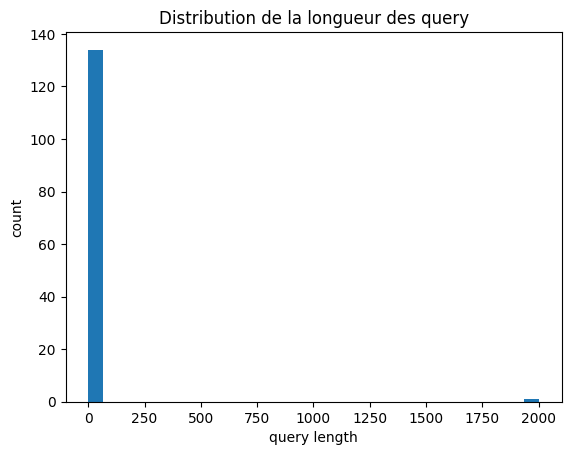

In [3]:
df_http["query_len"] = df_http["query"].fillna("").astype(str).str.len()

df_http["query_len"].plot(kind="hist", bins=30)
plt.title("Distribution de la longueur des query")
plt.xlabel("query length")
plt.ylabel("count")
plt.show()

### HTTP : scores du modèle

In [9]:
import sys
sys.path.append("../ml")

import joblib
import numpy as np
from feature_extraction import featurize_http

In [ ]:
model_http = joblib.load("../ml/model_http.joblib")

X_http = np.array([featurize_http(evt) for evt in rows], dtype=float)

scores_http = model_http.score_samples(X_http)
preds_http = model_http.predict(X_http)   # -1 anomalie, 1 normal

df_http["ml_score"] = scores_http
df_http["ml_pred"] = preds_http

df_http.head()


### Visualisation la distribution des scores HTTP

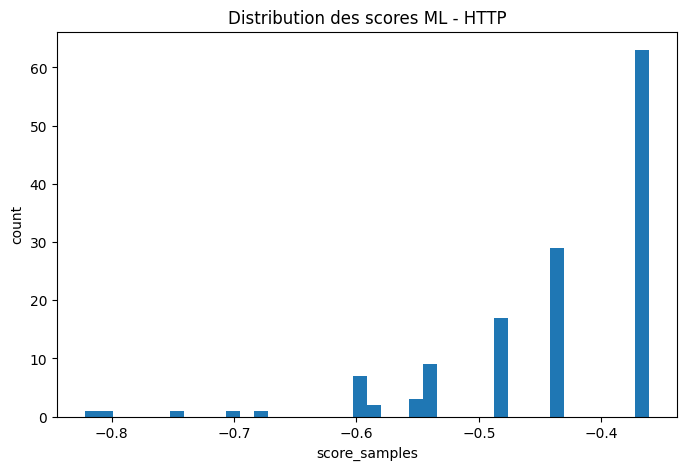

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_http["ml_score"], bins=40)
plt.title("Distribution des scores ML - HTTP")
plt.xlabel("score_samples")
plt.ylabel("count")
plt.show()

### les anomalies HTTP les plus suspectes

In [16]:
anomalies_http = df_http[df_http["ml_pred"] == -1].copy()
anomalies_http = anomalies_http.sort_values("ml_score")

anomalies_http[["path", "query", "user_agent", "ml_score"]].head(10)

,path,query,user_agent,ml_score
133,/search,q=AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,curl/7.81.0,-0.821597
134,/search,q=test,MyBrowser-XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...,-0.803417
43,/login,user=%27%20OR%201%3D1,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,-0.742745
115,/search,q=%3Cscript%3Ealert(1)%3C/script%3E,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,-0.697637
114,/login,q=%3Cscript%3Ealert(1)%3C/script%3E,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,-0.672008


### Taux d'anomalie HTTP

In [17]:
(len(df_http[df_http["ml_pred"] == -1]) / len(df_http)) * 100

3.7037037037037033

In [18]:
print("HTTP anomalies:", round((df_http["ml_pred"] == -1).mean() * 100, 2), "%")

HTTP anomalies: 3.7 %
